In [ ]:
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download paultimothymooney/chest-xray-pneumonia


mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 97% 2.23G/2.29G [00:26<00:02, 25.4MB/s]
100% 2.29G/2.29G [00:26<00:00, 92.4MB/s]


In [ ]:
!unzip /content/chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_ds =tf.keras.utils.image_dataset_from_directory(
    'chest_xray/train',
    image_size=(224,224),
    batch_size=32,
    color_mode='grayscale',
    shuffle=True
)

test_ds =tf.keras.utils.image_dataset_from_directory(
    'chest_xray/test',
    image_size=(224,224),
    batch_size=32,
    color_mode='grayscale',
    shuffle=False
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    'chest_xray/val',
    image_size=(224, 224),
    batch_size=32,
    color_mode='grayscale',
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


Class names: ['NORMAL', 'PNEUMONIA']


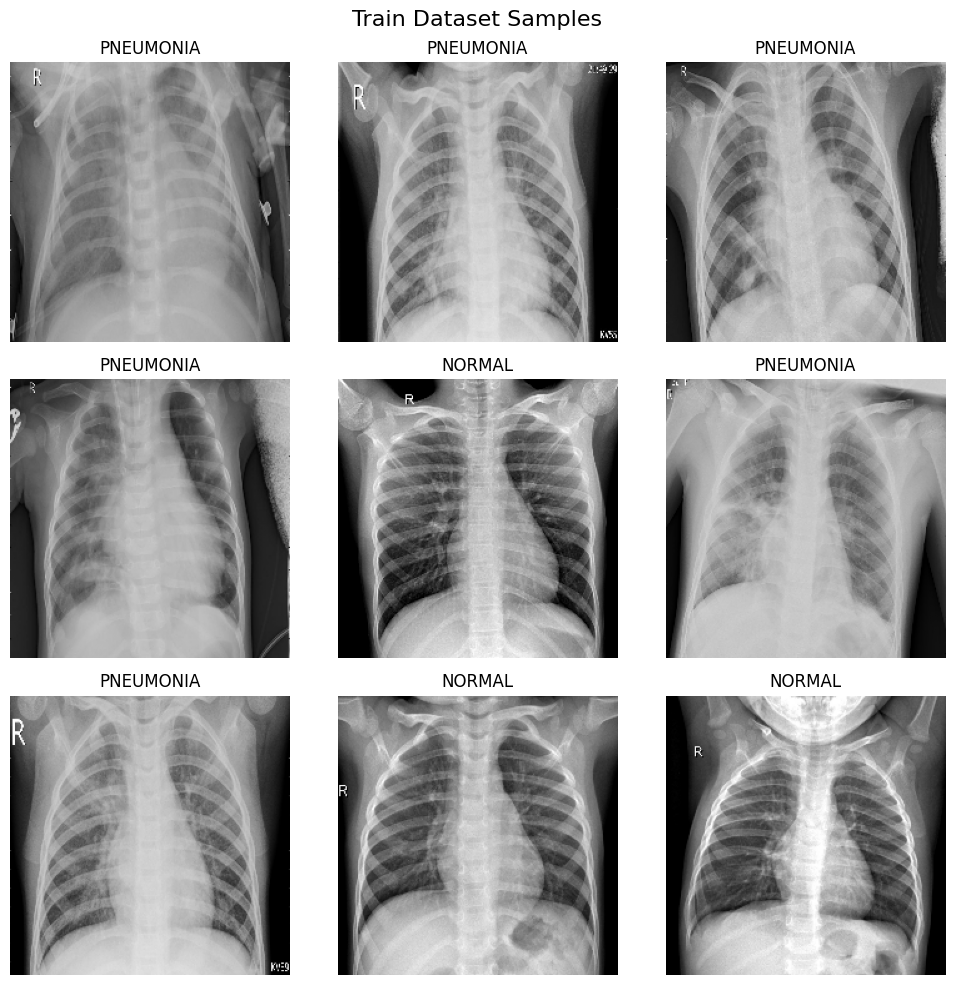

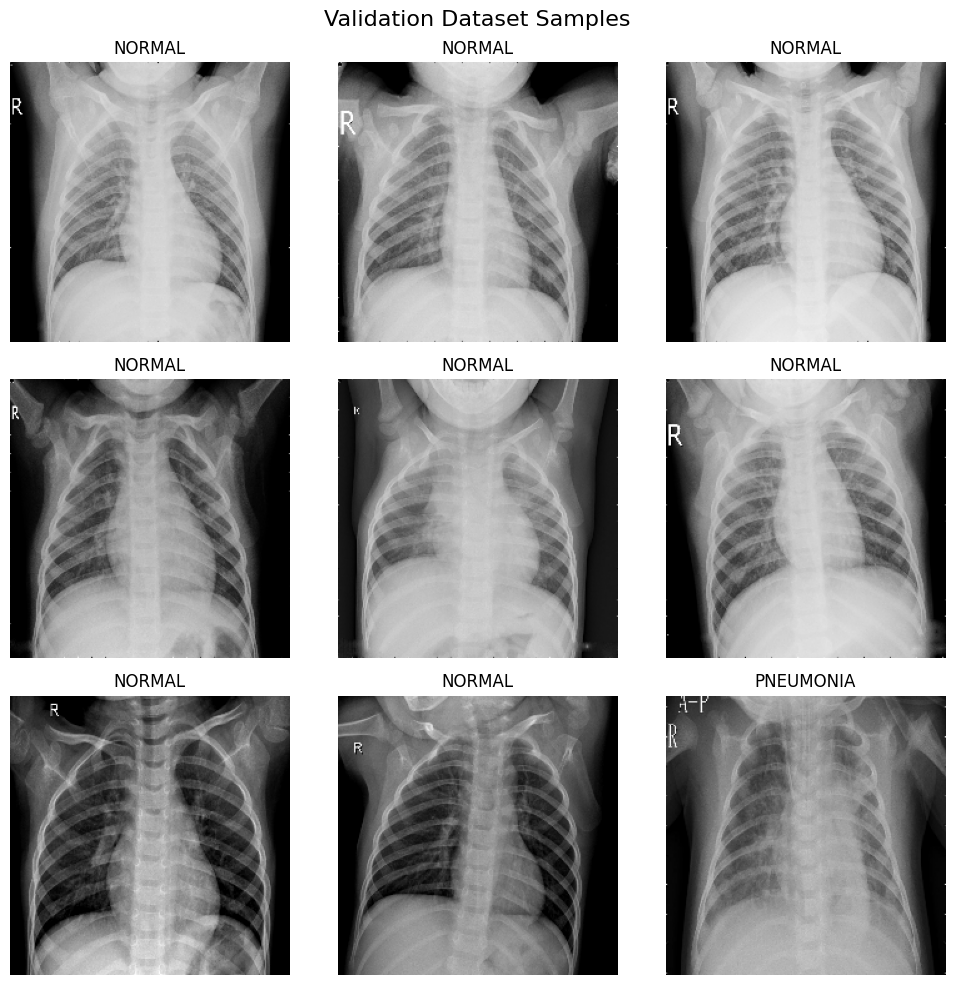

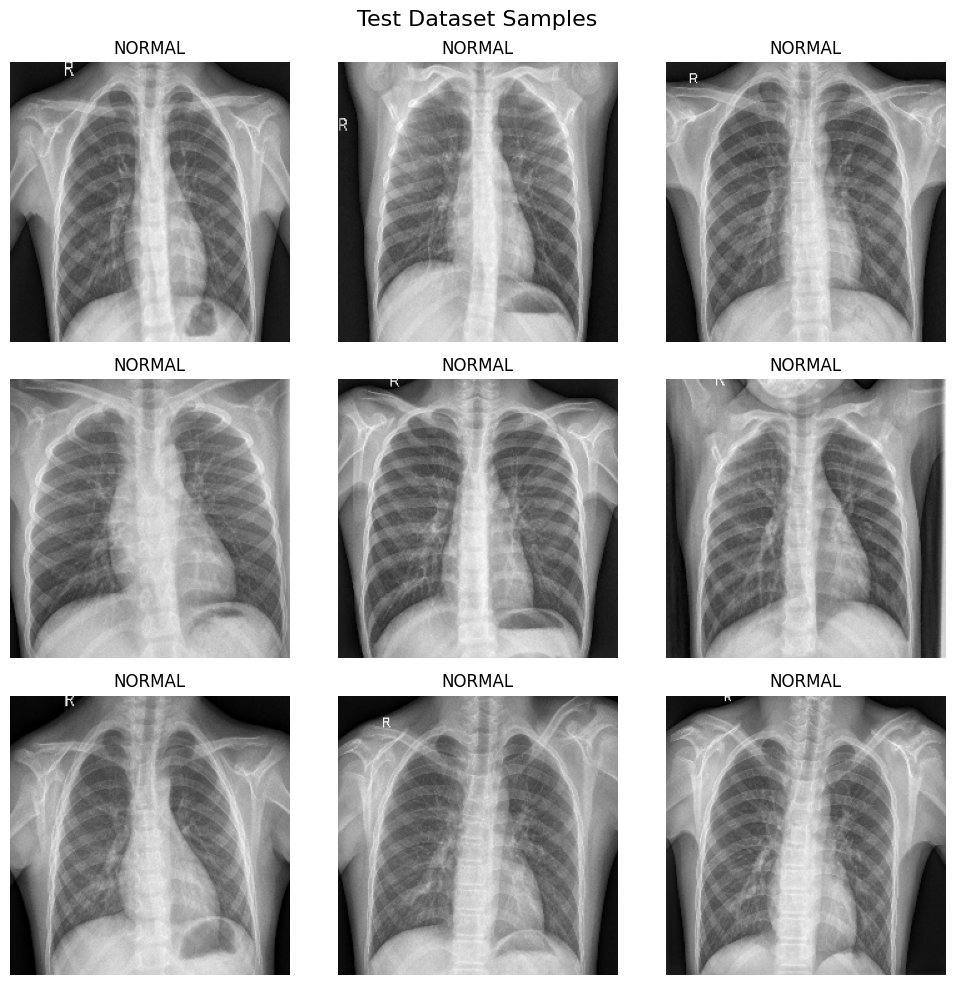

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_ds.class_names
print("Class names:", class_names)

def show_sample_images(dataset, title='Train Dataset Samples'):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            img = images[i].numpy().astype("uint8").squeeze()
            plt.imshow(img, cmap='gray')
            plt.title(class_names[labels[i]])
            plt.axis("off")
        plt.suptitle(title, fontsize=16)
        plt.tight_layout()
        plt.show()

show_sample_images(train_ds, 'Train Dataset Samples')
show_sample_images(val_ds, 'Validation Dataset Samples')
show_sample_images(test_ds, 'Test Dataset Samples')

In [ ]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)
test_ds = test_ds.map(normalize)

In [ ]:
import cv2
import numpy as np

def apply_clahe_to_tensor(tensor):
    images = []
    for img in tensor.numpy():
        img = img.squeeze() * 255  # back to [0–255] range
        img = img.astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_clahe = clahe.apply(img)
        img_clahe = img_clahe[..., np.newaxis] / 255.0  # restore shape & scale
        images.append(img_clahe)
    return tf.convert_to_tensor(images, dtype=tf.float32)

def clahe_map_fn(images, labels):
    images = tf.py_function(func=apply_clahe_to_tensor, inp=[images], Tout=tf.float32)
    images.set_shape([None, 224, 224, 1])
    return images, labels


train_ds = train_ds.map(clahe_map_fn)
val_ds = val_ds.map(clahe_map_fn)
test_ds = test_ds.map(clahe_map_fn)


In [ ]:
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 1)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
])
def augment_grayscale_images(x, y):
    # Ensure shape is (batch, height, width, 1)
    x = tf.ensure_shape(x, [None, 224, 224, 1])
    x = data_augmentation(x, training=True)
    return x, y

train_ds = train_ds.map(augment_grayscale_images, num_parallel_calls=tf.data.AUTOTUNE)



In [ ]:
#to see the class balance
import os
normal_count = len(os.listdir('chest_xray/train/NORMAL'))
pneumonia_count = len(os.listdir('chest_xray/train/PNEUMONIA'))
print(f"NORMAL: {normal_count}, PNEUMONIA: {pneumonia_count}")

NORMAL: 1341, PNEUMONIA: 3875


In [ ]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
y_train = [0] * normal_count + [1] * pneumonia_count

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
for image, label in train_ds.take(1):
    print("Image shape:", image.shape)
    print("Image dtype:", image.dtype)
    print("Pixel range:", tf.reduce_min(image).numpy(), "to", tf.reduce_max(image).numpy())


Image shape: (32, 224, 224, 1)
Image dtype: <dtype: 'float32'>
Pixel range: 0.004434287 to 0.99856985


In [ ]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = tf.keras.Sequential([

                             tf.keras.layers.Input(shape=(224, 224,1)),
                             tf.keras.layers.Conv2D(3,(3,3),padding='same',activation='relu'),
                             base_model,
                             tf.keras.layers.Flatten(),
                             tf.keras.layers.Dense(2048, activation='relu'),
                             tf.keras.layers.Dense(1024, activation='relu'),
                             tf.keras.layers.Dense(512, activation='relu'),
                             tf.keras.layers.Dense(256, activation='relu'),
                             tf.keras.layers.Dense(128, activation='relu'),
                             tf.keras.layers.Dense(64, activation='relu'),
                             tf.keras.layers.Dense(32, activation='relu'),
                             tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
base_model.trainable =False

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy']
              )

In [ ]:
model.fit(train_ds,epochs=5,validation_data=test_ds,class_weight=class_weights)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.7513 - loss: 0.5547 - val_accuracy: 0.8285 - val_loss: 0.5446
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.9392 - loss: 0.1527 - val_accuracy: 0.8734 - val_loss: 0.3620
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.9525 - loss: 0.1273 - val_accuracy: 0.8622 - val_loss: 0.3873
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9407 - loss: 0.1482 - val_accuracy: 0.8558 - val_loss: 0.6240
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9677 - loss: 0.0946 - val_accuracy: 0.8894 - val_loss: 0.3061


In [ ]:
model.fit(train_ds,epochs=2,validation_data=val_ds,class_weight=class_weights)

Epoch 1/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 327s 2s/step - accuracy: 0.9592 - loss: 0.0957 - val_accuracy: 1.0000 - val_loss: 0.1371
Epoch 2/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9634 - loss: 0.0881 - val_accuracy: 1.0000 - val_loss: 0.0731


In [ ]:
import numpy as np
predictions = model.predict(test_ds)
# Convert probabilities to class labels (0 or 1)
predicted_labels = (predictions > 0.5).astype(int)
true_labels = []
for _, label in test_ds.unbatch():
    true_labels.append(int(label.numpy()))
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(true_labels, predicted_labels))
print(confusion_matrix(true_labels, predicted_labels))

20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step
              precision    recall  f1-score   support

           0       0.93      0.74      0.82       234
           1       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624

[[172  62]
 [ 12 378]]
